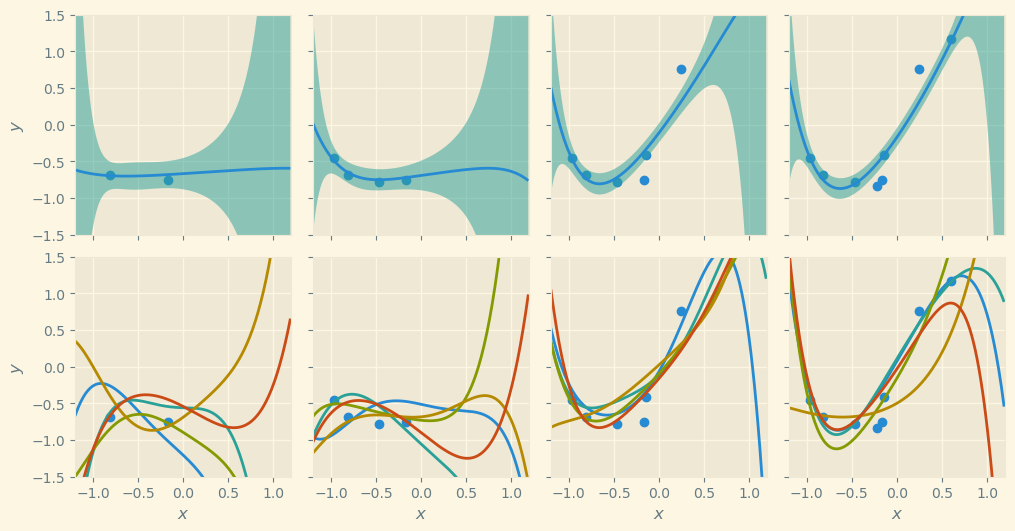

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
import scipy.stats as st


def true_fun(X):
    return np.sin(np.pi * X)


np.random.seed(1)
n_samples, degree, lines = 8, 4, 5  # 4阶多项式
a, b = 1, 10  # 分布超参数
mu, sigma = np.zeros(degree + 1), np.eye(degree + 1) / a  # w的先验高斯分布的参数
x, y = [], []  # 保存样本 用于画散点图
Xy = np.zeros((degree + 1, 1))  # sum_i x_i y_i

x_plot = np.arange(-1.2, 1.2, 0.01)
polynomial_features = PolynomialFeatures(degree=degree, include_bias=True)
xx_plot = polynomial_features.fit_transform(x_plot[:, np.newaxis])

with plt.style.context('Solarize_Light2'):
    fig, ax = plt.subplots(2, int(n_samples / 2), sharex=True, sharey=True, figsize=(12, 6))
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    plt.setp(ax, xlim=(-1.2, 1.2), ylim=(-1.5, 1.5))

    for i in range(n_samples):
        xi = st.uniform.rvs(loc=-1, scale=2)  # [-1,1]上均匀采样
        yi = true_fun(xi) + st.norm.rvs(loc=0, scale=np.sqrt(1 / b))
        x.append(xi)
        y.append(yi)
        xi = polynomial_features.fit_transform([[xi]]).reshape(degree + 1, 1)
        Xy += xi * yi
        sigma = sigma - b * sigma @ xi @ xi.T @ sigma / (1 + b * xi.T @ sigma @ xi)  # Sherman-Morrison 公式
        mu = b * (sigma @ Xy)

        if i & 1:
            j = int(i / 2)
            m = (xx_plot @ mu).ravel()  # 预测分布的均值
            ax[0, j].scatter(x, y)
            ax[0, j].plot(x_plot, m)
            ax[0, j].fill_between(x_plot, m - 1 / b - np.diag(xx_plot @ sigma @ xx_plot.T), m + 1 / b + np.diag(xx_plot @ sigma @ xx_plot.T), alpha=0.5)

            ax[1, j].scatter(x, y)
            W = st.multivariate_normal.rvs(mean=mu.ravel(), cov=sigma, size=lines)
            for k in range(lines):
                ax[1, j].plot(x_plot, xx_plot @ W[k, :])
                ax[1, j].set_xlabel(r'$x$')
            if i == 1:
                ax[0, j].set_ylabel(r'$y$')
                ax[1, j].set_ylabel(r'$y$')

    #fig.savefig("predictive-distribution.svg")
    plt.show()